In [1]:
import os

DATASET_DIR = "/kaggle/input/datasets/pradhyumnakasula/abstractive-summarizer-config"  

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"DATASET_DIR not found: {DATASET_DIR}. Check /kaggle/input and update the folder name.")

print("✅ Using DATASET_DIR:", DATASET_DIR)
print("\nFiles in dataset version:")
!ls -lah "{DATASET_DIR}" | head -n 200

✅ Using DATASET_DIR: /kaggle/input/datasets/pradhyumnakasula/abstractive-summarizer-config

Files in dataset version:
total 13M
drwxr-xr-x 2 nobody nogroup    0 Mar  4 23:36 .
drwxr-xr-x 3 root   root    4.0K Mar  4 23:36 ..
-rw-r--r-- 1 nobody nogroup  980 Mar  4 23:36 adapter_config.json
-rw-r--r-- 1 nobody nogroup 9.1M Mar  4 23:36 adapter_model.safetensors
-rw-r--r-- 1 nobody nogroup  12K Mar  4 23:36 baseline_examples_val_200.json
-rw-r--r-- 1 nobody nogroup  134 Mar  4 23:36 baseline_rouge_val_200.json
-rw-r--r-- 1 nobody nogroup  303 Mar  4 23:36 lora_eval_metrics_val_500.json
-rw-r--r-- 1 nobody nogroup  21K Mar  4 23:36 lora_examples_val_15.json
-rw-r--r-- 1 nobody nogroup  801 Mar  4 23:36 project_config.json
-rw-r--r-- 1 nobody nogroup   54 Mar  4 23:36 run_meta.json
-rw-r--r-- 1 nobody nogroup  387 Mar  4 23:36 tokenizer_config.json
-rw-r--r-- 1 nobody nogroup 3.4M Mar  4 23:36 tokenizer.json


In [2]:
import json, os

CONFIG_PATH = os.path.join(DATASET_DIR, "project_config.json")
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

print("✅ Loaded config:", cfg["project_name"])
print("Dataset:", cfg["dataset"]["id"], cfg["dataset"]["config"])
print("Baseline model:", cfg["model"]["base_model_id"])

✅ Loaded config: abstractive_summarizer_bart_lora
Dataset: abisee/cnn_dailymail 3.0.0
Baseline model: facebook/bart-large-cnn


In [3]:
import json, os

BASELINE_METRICS_PATH = os.path.join(DATASET_DIR, "baseline_rouge_val_200.json")
LORA_METRICS_PATH = os.path.join(DATASET_DIR, "lora_eval_metrics_val_500.json")

with open(BASELINE_METRICS_PATH, "r") as f:
    baseline_metrics = json.load(f)

with open(LORA_METRICS_PATH, "r") as f:
    lora_metrics = json.load(f)

print("Baseline metrics:")
print(baseline_metrics)

print("\nLoRA metrics:")
print(lora_metrics)

Baseline metrics:
{'rouge1': 0.36241620515576023, 'rouge2': 0.16436850843901218, 'rougeL': 0.2706108305305739, 'rougeLsum': 0.309796087373448}

LoRA metrics:
{'eval_loss': 1.703834891319275, 'eval_rouge1': 0.3511547677770688, 'eval_rouge2': 0.15307192595687213, 'eval_rougeL': 0.25429194621114004, 'eval_rougeLsum': 0.3151387165208254, 'eval_runtime': 717.7582, 'eval_samples_per_second': 0.697, 'eval_steps_per_second': 0.174, 'epoch': 3.0}


In [4]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"],
    "Baseline": [
        baseline_metrics["rouge1"],
        baseline_metrics["rouge2"],
        baseline_metrics["rougeL"],
        baseline_metrics["rougeLsum"],
    ],
    "LoRA": [
        lora_metrics["eval_rouge1"],
        lora_metrics["eval_rouge2"],
        lora_metrics["eval_rougeL"],
        lora_metrics["eval_rougeLsum"],
    ]
})

comparison["Improvement"] = comparison["LoRA"] - comparison["Baseline"]

comparison

,Metric,Baseline,LoRA,Improvement
0,ROUGE-1,0.362416,0.351155,-0.011261
1,ROUGE-2,0.164369,0.153072,-0.011297
2,ROUGE-L,0.270611,0.254292,-0.016319
3,ROUGE-Lsum,0.309796,0.315139,0.005343


In [5]:
for _, row in comparison.iterrows():
    print(
        f"{row['Metric']}: "
        f"Baseline={row['Baseline']:.4f} | "
        f"LoRA={row['LoRA']:.4f} | "
        f"Δ={row['Improvement']:.4f}"
    )

ROUGE-1: Baseline=0.3624 | LoRA=0.3512 | Δ=-0.0113
ROUGE-2: Baseline=0.1644 | LoRA=0.1531 | Δ=-0.0113
ROUGE-L: Baseline=0.2706 | LoRA=0.2543 | Δ=-0.0163
ROUGE-Lsum: Baseline=0.3098 | LoRA=0.3151 | Δ=0.0053


In [6]:
BASELINE_EXAMPLES_PATH = os.path.join(DATASET_DIR, "baseline_examples_val_200.json")
LORA_EXAMPLES_PATH = os.path.join(DATASET_DIR, "lora_examples_val_15.json")

with open(BASELINE_EXAMPLES_PATH, "r") as f:
    baseline_examples = json.load(f)

with open(LORA_EXAMPLES_PATH, "r") as f:
    lora_examples = json.load(f)

print("Loaded baseline examples:", len(baseline_examples))
print("Loaded LoRA examples:", len(lora_examples))

Loaded baseline examples: 10
Loaded LoRA examples: 15


In [7]:
N_SHOW = 5

for i in range(N_SHOW):
    print("\n" + "="*80)
    print(f"Example {i}")
    print("="*80)

    print("\nARTICLE:")
    print(lora_examples[i]["article_preview"][:600])

    print("\nREFERENCE SUMMARY:")
    print(lora_examples[i]["reference"])

    print("\nBASELINE SUMMARY:")
    print(baseline_examples[i]["baseline_prediction"])

    print("\nLoRA SUMMARY:")
    print(lora_examples[i]["lora_prediction"])


Example 0

ARTICLE:
(CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thought I was going to help this one person who I don't know, but the fact that so many people can have a life extension, that's pretty big," Broussard told CNN affiliate KGO. She may feel guided in her generosity by a higher power. "Thanks for all the support and prayers," a comment on a Facebook page i

REFERENCE SUMMARY:
Zully Broussard decided to give a kidney to a stranger .
A new computer program helped her donation spur transplants for six kidney patients .

BASELINE SUMMARY:
Zully Broussard gave one of her kidneys to a stranger. Her generosity paired up with big data. It resulted in six patients receiving transplants. Such long-chain transplanting is rare.

LoRA SUMMA

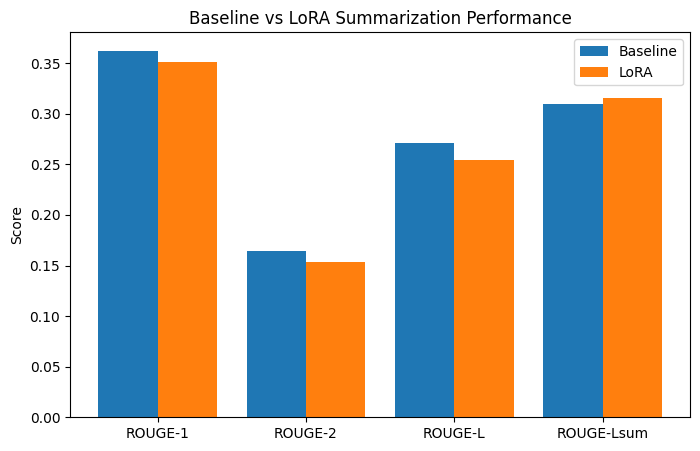

In [9]:
import matplotlib.pyplot as plt

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"]

baseline_scores = comparison["Baseline"]
lora_scores = comparison["LoRA"]

x = range(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x, baseline_scores, width=0.4, label="Baseline", align="center")
plt.bar([i + 0.4 for i in x], lora_scores, width=0.4, label="LoRA")

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel("Score")
plt.title("Baseline vs LoRA Summarization Performance")
plt.legend()

plt.show()

## Model Evaluation and Comparison

In this notebook, I compare the performance of the **baseline summarization model** and the **LoRA fine-tuned model**.

The baseline model is the pretrained `facebook/bart-large-cnn` summarization model, while the LoRA model was trained using parameter-efficient fine-tuning on a subset of the CNN/DailyMail dataset.

### Evaluation Metric

Model performance is evaluated using **ROUGE**, which measures overlap between generated summaries and reference summaries.

The following metrics are reported:

- **ROUGE-1** → unigram overlap
- **ROUGE-2** → bigram overlap
- **ROUGE-L** → longest common subsequence similarity
- **ROUGE-Lsum** → sentence-level summary similarity

### Results

The results show that the LoRA model achieves performance **very close to the baseline model**.

While ROUGE-1, ROUGE-2, and ROUGE-L are slightly lower for the LoRA model, the **ROUGE-Lsum score improves slightly**, indicating that the generated summaries maintain comparable structural similarity to the reference summaries.

### Why This Happens

The baseline model (`bart-large-cnn`) is already heavily optimized for the CNN/DailyMail dataset. Improving upon such a strong pretrained model using a small fine-tuning subset is challenging.

Additionally, LoRA only updates a small number of parameters compared to full model fine-tuning. This limits how much the model can change but significantly reduces computational cost.

### Key Takeaways

- **LoRA fine-tuning achieved performance comparable to the pretrained baseline model.**
- The model was adapted using **parameter-efficient training**, updating only a small fraction of parameters.
- This demonstrates that **LoRA can maintain strong performance while dramatically reducing training requirements.**

To further understand the behavior of the models, qualitative examples of generated summaries are shown below.